<a href="https://colab.research.google.com/github/gk2311/AIHC5020/blob/main/Final_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install google-cloud-storage pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.1 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom

from google.cloud import storage

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# Problem 1

In [ ]:
# String representation.
data_types = [
    {
        "name": "Integer",
        "python_symbol": "int",
        "example": str(25),
        "falsy_value": str(0),
        "usage": "Represents whole numbers"
    },
    {
        "name": "Float",
        "python_symbol": "float",
        "example": str(3.14),
        "falsy_value": str(0.0),
        "usage": "Represents decimal or floating-point numbers"
    },
    {
        "name": "Complex",
        "python_symbol": "complex",
        "example": str(2 + 3j),
        "falsy_value": str(0j),
        "usage": "Represents numbers with real and imaginary components"
    },
    {
        "name": "Boolean",
        "python_symbol": "bool",
        "example": str(True),
        "falsy_value": str(False),
        "usage": "Represents logical True or False values"
    },
    {
        "name": "String",
        "python_symbol": "str",
        "example": str("Hello"),
        "falsy_value": str(""),
        "usage": "Represents text or sequences of characters"
    },
    {
        "name": "NoneType",
        "python_symbol": "None",
        "example": str(None),
        "falsy_value": str(None),
        "usage": "Represents the absence of a value"
    },
    {
        "name": "List",
        "python_symbol": "list",
        "example": str([1, 2, 3]),
        "falsy_value": str([]),
        "usage": "Stores an ordered, mutable collection of values"
    },
    {
        "name": "Tuple",
        "python_symbol": "tuple",
        "example": str((1, 2, 3)),
        "falsy_value": str(()),
        "usage": "Stores an ordered, immutable collection of values"
    },
    {
        "name": "Dictionary",
        "python_symbol": "dict",
        "example": str({"name": "Alice", "age": 25}),
        "falsy_value": str({}),
        "usage": "Stores key-value pairs"
    }
]

data_types_df = pd.DataFrame(data_types)

data_types_df

,name,python_symbol,example,falsy_value,usage
0,Integer,int,25,0,Represents whole numbers
1,Float,float,3.14,0.0,Represents decimal or floating-point numbers
2,Complex,complex,(2+3j),0j,Represents numbers with real and imaginary com...
3,Boolean,bool,True,False,Represents logical True or False values
4,String,str,Hello,,Represents text or sequences of characters
5,NoneType,None,None,None,Represents the absence of a value
6,List,list,"[1, 2, 3]",[],"Stores an ordered, mutable collection of values"
7,Tuple,tuple,"(1, 2, 3)",(),"Stores an ordered, immutable collection of values"
8,Dictionary,dict,"{'name': 'Alice', 'age': 25}",{},Stores key-value pairs


# Problem 2

In [ ]:
def _id_matches_filename(blob_name, chat_log_id):
    """
    Check whether chat_log_id occurs as a complete numeric component
    in the file name, avoiding matches such as 101 matching 1010.
    """
    file_name = Path(blob_name).name

    return re.search(
        rf"(?<!\d){re.escape(str(chat_log_id))}(?!\d)",
        file_name
    ) is not None


def _find_timestamp_column(columns):
    """
    Find the most likely Unix-microsecond timestamp column.
    """
    preferred_names = [
        "timestamp_usec",
        "timestamp_us",
        "timestamp_micros",
        "timestamp_microseconds",
        "create_time_usec",
        "create_time_us",
        "time_usec",
        "time_us",
        "timestamp",
        "time"
    ]

    # First look for an exact match, ignoring capitalization.
    lower_to_original = {str(col).lower(): col for col in columns}

    for candidate in preferred_names:
        if candidate in lower_to_original:
            return lower_to_original[candidate]

    # Then look for a nested or similarly named column.
    for col in columns:
        normalized = str(col).lower()

        if (
            "timestamp" in normalized
            or "time_usec" in normalized
            or "time_us" in normalized
            or "microsecond" in normalized
        ):
            return col

    return None


def load_chat_log(chat_log_id):
    """
    Load a chat-log JSON file from Google Cloud Storage.

    Parameters
    ----------
    chat_log_id : int
        Integer identifier for the requested chat log.

    Returns
    -------
    pandas.DataFrame or None
        Log-table DataFrame if the file is found; otherwise None.
    """
    if isinstance(chat_log_id, bool) or not isinstance(
        chat_log_id, (int, np.integer)
    ):
        raise TypeError("chat_log_id must be an integer.")

    bucket_name = "cloud-samples-data"
    prefix = "ccai/sample-chat-logs"

    # The bucket is public, so no user credentials are required.
    client = storage.Client.create_anonymous_client()
    bucket = client.bucket(bucket_name)

    blobs = list(client.list_blobs(bucket_name, prefix=prefix))

    matching_blobs = [
        blob
        for blob in blobs
        if blob.name.lower().endswith(".json")
        and _id_matches_filename(blob.name, chat_log_id)
    ]

    if len(matching_blobs) == 0:
        print(f"No chat log file was found for ID {chat_log_id}.")
        return None

    # Prefer the shortest matching name if more than one file matches.
    matching_blobs.sort(key=lambda blob: (len(blob.name), blob.name))
    selected_blob = matching_blobs[0]

    print(f"Loading: gs://{bucket_name}/{selected_blob.name}")

    json_text = selected_blob.download_as_text()
    chat_data = json.loads(json_text)

    # Handle common JSON structures.
    if isinstance(chat_data, list):
        messages = chat_data

    elif isinstance(chat_data, dict):
        possible_message_keys = [
            "messages",
            "entries",
            "chat_messages",
            "conversation",
            "transcript",
            "records"
        ]

        messages = None

        for key in possible_message_keys:
            if key in chat_data and isinstance(chat_data[key], list):
                messages = chat_data[key]
                break

        # If no list-valued message key exists, treat the object
        # itself as one record.
        if messages is None:
            messages = [chat_data]

    else:
        print(
            f"The chat log for ID {chat_log_id} has an "
            "unsupported JSON structure."
        )
        return None

    chat_df = pd.json_normalize(messages, sep="_")

    if chat_df.empty:
        print(f"The chat log for ID {chat_log_id} contains no messages.")
        return chat_df

    timestamp_column = _find_timestamp_column(chat_df.columns)

    if timestamp_column is None:
        print(
            "The file was loaded, but a timestamp column "
            "could not be identified."
        )
        return chat_df

    numeric_timestamp = pd.to_numeric(
        chat_df[timestamp_column],
        errors="coerce"
    )

    # Unix timestamps in this assignment are measured in microseconds.
    converted_timestamp = pd.to_datetime(
        numeric_timestamp,
        unit="us",
        origin="unix",
        utc=True,
        errors="coerce"
    )

    # Make a new DataFrame rather than modifying a possible view.
    chat_df = chat_df.copy()

    chat_df["datetime"] = converted_timestamp.dt.strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    # Keep the human-readable datetime as the first column.
    remaining_columns = [
        col
        for col in chat_df.columns
        if col not in {"datetime", timestamp_column}
    ]

    chat_df = chat_df[
        ["datetime", timestamp_column] + remaining_columns
    ]

    # Sort the time series chronologically.
    chat_df = chat_df.sort_values(
        by=timestamp_column,
        kind="stable"
    ).reset_index(drop=True)

    return chat_df

In [ ]:
chat_101_df = load_chat_log(101)

if chat_101_df is not None:
    display(chat_101_df)

Loading: gs://cloud-samples-data/ccai/sample-chat-logs/chat_101.json


,datetime,start_timestamp_usec,text,role,user_id
0,2023-02-23 02:07:40,1677118060000000,"Hello, how can I assist you today?",AGENT,2
1,2023-02-23 02:07:58,1677118078000000,"Hi, I'm having an issue with my laptop",CUSTOMER,1
2,2023-02-23 02:08:16,1677118096000000,Sorry to hear. Can you tell me what the proble...,AGENT,2
3,2023-02-23 02:08:34,1677118114000000,The laptop is not connecting to the internet. ...,CUSTOMER,1
4,2023-02-23 02:08:52,1677118132000000,Can you give me more details about the problem...,AGENT,2
5,2023-02-23 02:09:10,1677118150000000,The problem with the laptop is still happening...,CUSTOMER,1
6,2023-02-23 02:09:28,1677118168000000,And what is the status shown in the settings o...,AGENT,2
7,2023-02-23 02:09:46,1677118186000000,Warning: No available storage. Your computer's...,CUSTOMER,1
8,2023-02-23 02:10:04,1677118204000000,Can you tell me your account number?,AGENT,2
9,2023-02-23 02:10:22,1677118222000000,"Sure, it's 407106565",CUSTOMER,1


In [ ]:
missing_chat_df = load_chat_log(999999999)

No chat log file was found for ID 999999999.


# Problem 3

In [ ]:
def _looks_like_dicom(file_path):
    try:
        with open(file_path, "rb") as f:
            f.seek(128)
            return f.read(4) == b"DICM"
    except Exception:
        return False


def _val(ds, attr, default=""):
    v = getattr(ds, attr, None)
    if v is None:
        return default
    return str(v)


def build_dicom_manifest(dicom_folder, strict_dicom=True, verbose=True):
    root = Path(dicom_folder)
    if not root.is_dir():
        raise NotADirectoryError("Not a valid directory: " + str(root))

    records = {}
    n_seen = 0
    n_skipped = 0
    n_read = 0

    for fp in root.rglob("*"):
        if not fp.is_file():
            continue
        if fp.name.startswith("."):
            continue

        n_seen += 1

        ok_ext = fp.suffix.lower() in (".dcm", ".dicom", "")
        if strict_dicom and not _looks_like_dicom(fp) and not ok_ext:
            n_skipped += 1
            continue

        try:
            ds = pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
        except Exception:
            n_skipped += 1
            continue

        if len(ds) == 0:
            n_skipped += 1
            continue

        n_read += 1
        series_uid = _val(ds, "SeriesInstanceUID")
        if series_uid:
            key = series_uid
        else:
            key = "DIR::" + str(fp.parent.resolve())

        if key not in records:
            records[key] = {
                "series_uid": series_uid or "UNKNOWN",
                "study_uid": _val(ds, "StudyInstanceUID", "UNKNOWN"),
                "patient_id": _val(ds, "PatientID", "UNKNOWN"),
                "study_date": _val(ds, "StudyDate", "UNKNOWN"),
                "modality": _val(ds, "Modality", "UNKNOWN"),
                "number_of_images": 0,
                "series_directory": str(fp.parent.resolve()),
            }

        records[key]["number_of_images"] += 1

    cols = [
        "series_uid",
        "study_uid",
        "patient_id",
        "study_date",
        "modality",
        "number_of_images",
        "series_directory",
    ]

    manifest_df = pd.DataFrame(list(records.values()), columns=cols)

    if not manifest_df.empty:
        manifest_df = manifest_df.sort_values(
            ["patient_id", "study_date", "series_uid"], kind="stable"
        ).reset_index(drop=True)

    if verbose:
        print("Files scanned:", n_seen, "| read as DICOM:", n_read,
              "| skipped:", n_skipped)
        print("Series in manifest:", len(manifest_df))

    return manifest_df


manifest_df = build_dicom_manifest(
    "/content/drive/MyDrive/AIHC5020/dicom/chest_xray"
)
manifest_df.head()

Files scanned: 72 | read as DICOM: 72 | skipped: 0
Series in manifest: 33


,series_uid,study_uid,patient_id,study_date,modality,number_of_images,series_directory
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...,1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...,LIDC-IDRI-0001,20000101,DX,2,/content/drive/.shortcut-targets-by-id/1LsGJik...
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...,1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...,LIDC-IDRI-0002,20000101,DX,1,/content/drive/.shortcut-targets-by-id/1LsGJik...
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.142026812390...,1.3.6.1.4.1.14519.5.2.1.6279.6001.202063331127...,LIDC-IDRI-0003,20000101,DX,5,/content/drive/.shortcut-targets-by-id/1LsGJik...
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.126797645619...,1.3.6.1.4.1.14519.5.2.1.6279.6001.263497132244...,LIDC-IDRI-0005,20000101,DX,2,/content/drive/.shortcut-targets-by-id/1LsGJik...
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.188744668142...,1.3.6.1.4.1.14519.5.2.1.6279.6001.618422555692...,LIDC-IDRI-0006,20000101,DX,2,/content/drive/.shortcut-targets-by-id/1LsGJik...


# Problem 4

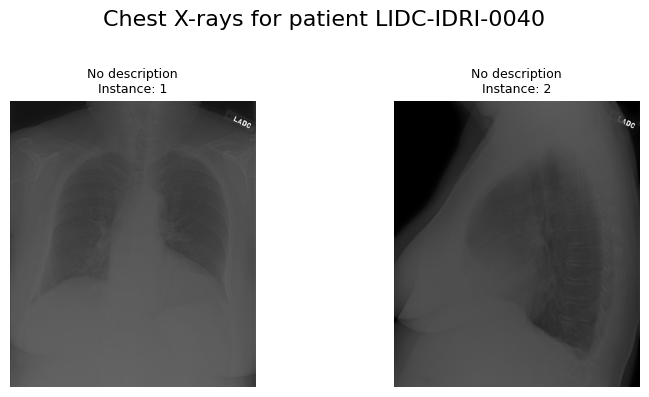

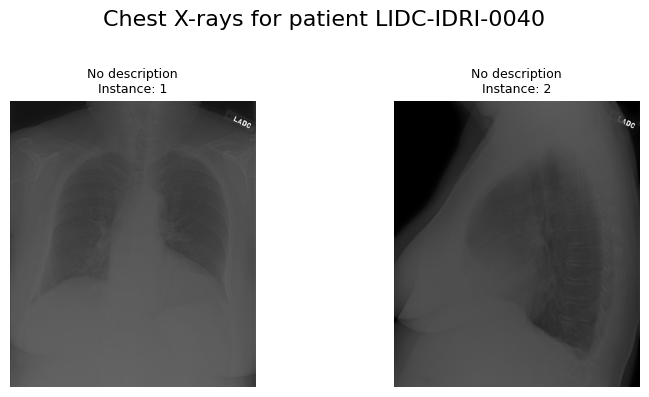

In [ ]:
def prepare_dicom_image(ds):
    image = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    image = image * slope + intercept

    photometric = str(getattr(ds, "PhotometricInterpretation", "")).upper()
    if photometric == "MONOCHROME1":
        image = image.max() - image

    return image


def collect_patient_instances(patient_manifest):
    instances = []

    for _, row in patient_manifest.iterrows():
        series_uid = str(row["series_uid"])
        series_dir = Path(row["series_directory"])

        if not series_dir.is_dir():
            print("Warning: missing directory " + str(series_dir))
            continue

        for fp in series_dir.rglob("*"):
            if not fp.is_file():
                continue
            if fp.name.startswith("."):
                continue

            try:
                ds = pydicom.dcmread(str(fp), force=True)
            except Exception:
                continue

            if len(ds) == 0:
                continue
            if not hasattr(ds, "PixelData"):
                continue

            file_uid = str(getattr(ds, "SeriesInstanceUID", ""))
            if series_uid != "UNKNOWN" and file_uid != series_uid:
                continue

            raw_number = getattr(ds, "InstanceNumber", None)
            try:
                number = int(raw_number)
            except (TypeError, ValueError):
                number = 10 ** 9

            instances.append({
                "series_uid": file_uid,
                "instance_number": number,
                "file_path": str(fp),
                "dataset": ds,
            })

    instances.sort(key=lambda d: (d["series_uid"],
                                  d["instance_number"],
                                  d["file_path"]))
    return instances


def visualize_patient_xrays(patient_id, manifest_df):
    mask = manifest_df["patient_id"].astype(str) == str(patient_id)
    patient_manifest = manifest_df.loc[mask].copy()

    if patient_manifest.empty:
        print("Patient '" + str(patient_id) + "' was not found in the manifest.")
        return None

    instances = collect_patient_instances(patient_manifest)

    if len(instances) == 0:
        print("Patient found, but no readable image instances were available.")
        return None

    n = len(instances)
    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols,
                             figsize=(4 * ncols, 4 * nrows),
                             squeeze=False)

    flat_axes = axes.ravel()

    for axis, item in zip(flat_axes, instances):
        ds = item["dataset"]
        try:
            axis.imshow(prepare_dicom_image(ds), cmap="gray")
            desc = str(getattr(ds, "SeriesDescription", "No description"))
            num = item["instance_number"]
            label = "Unknown" if num == 10 ** 9 else str(num)
            axis.set_title(desc + "\nInstance: " + label, fontsize=9)
        except Exception as err:
            axis.text(0.5, 0.5, "Unable to display\n" + str(err),
                      ha="center", va="center", wrap=True)
        axis.axis("off")

    for axis in flat_axes[n:]:
        axis.axis("off")

    fig.suptitle("Chest X-rays for patient " + str(patient_id), fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return fig


visualize_patient_xrays("LIDC-IDRI-0040", manifest_df)